In [1]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from create_data_products import CreateDataProducts

In [2]:
CREATOR    = 'Matthew Murphy'
EMAIL      = 'mmmurphy@msu.edu'
TARGET     = 'V1298Tauc'
INSTRUMENT = 'NIRISS'
ELEMENT    = 'SOSS'
PIPELINE   = 'ExoTEDRF'
STAGE2     = '/Users/belugawhale/Downloads/jw05959002001_04102_00001-seg001_nis_x1dints.fits'

In [3]:
cdp = CreateDataProducts(creator=CREATOR, creator_email=EMAIL,
                         target=TARGET, instrument=INSTRUMENT, element=ELEMENT,
                         pipeline=PIPELINE, stage2_file=STAGE2)

## Stellar Spectra Products (NIRISS) - ✔️

In [14]:
filename = '/Users/belugawhale/Downloads/V1298Tau-c-timeseries-spectra/V1298 Tau_box_spectra_ap40_fullres.fits'
filename_fluxcal = '/Users/belugawhale/Downloads/V1298Tau-c-timeseries-spectra/V1298 Tau_box_spectra_fullres_FluxCalibrated.fits'

cdp.stellar_spectra_niriss(filename=filename, overwrite=True)
cdp.stellar_spectra_niriss(filename=filename_fluxcal, flux_calibrated=True, overwrite=True)

## Transmission Spectra - ✔️

In [5]:
directory = '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/'
filenames = [os.path.join(directory, i) for i in os.listdir(directory)]
filenames

['/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest4_R300.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest4_R100.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest1_R50.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest4_R50.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest2_6spots_R300.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest2_6spots_R100.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest2_6spots_R50.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest3_6spots_R300.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest3_6spots_R100.txt',
 '/Users/belugawhale/Downloads/V1298Tau-c-transmission-spectra/V1298Tauc_SOSS_LCtest1_R100.txt'

In [6]:
cases = [4,4,1,4,2,2,2,3,3,1,3,1]
resolutions = [300,100,50,50,300,100,50,300,100,100,50,300]

In [7]:
cdp.transmission_spec(filenames, resolutions, cases)

## Check

In [8]:
new = fits.open('hlsp_kronos_jwst_niriss_v1298tauc_exotedrf_v1_transmission-spectra.fits')

In [9]:
new[6].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   32 / length of dimension 1                          
NAXIS2  =                   55 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    4 / number of table fields                         
EXTNAME = 'TRANSMISSION SPECTRUM' / extension name                              
TTYPE1  = 'wave    '                                                            
TFORM1  = 'D       '                                                            
TTYPE2  = 'wave_err'                                                            
TFORM2  = 'D       '        

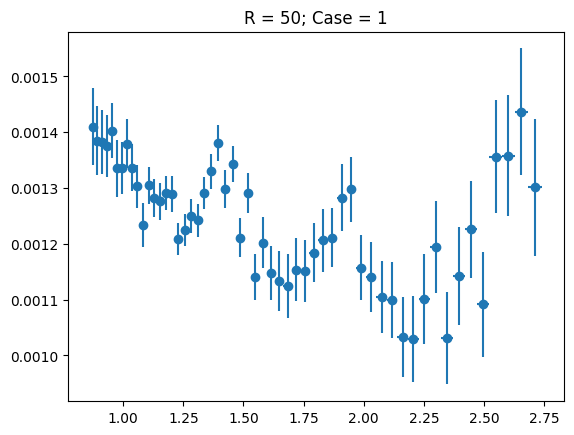

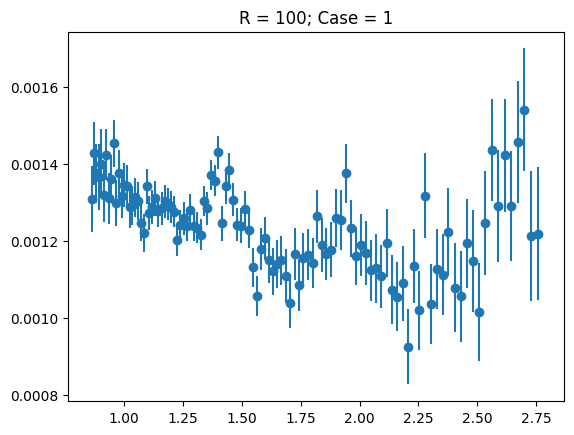

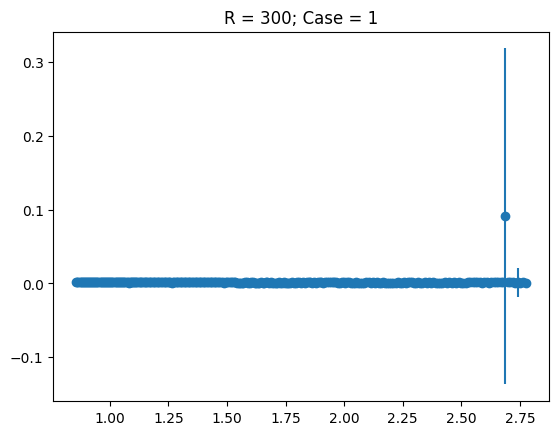

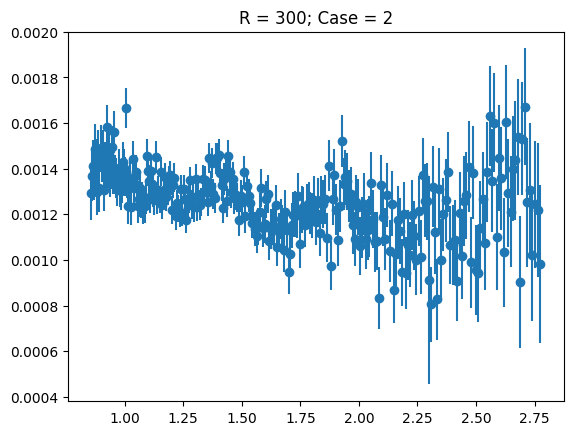

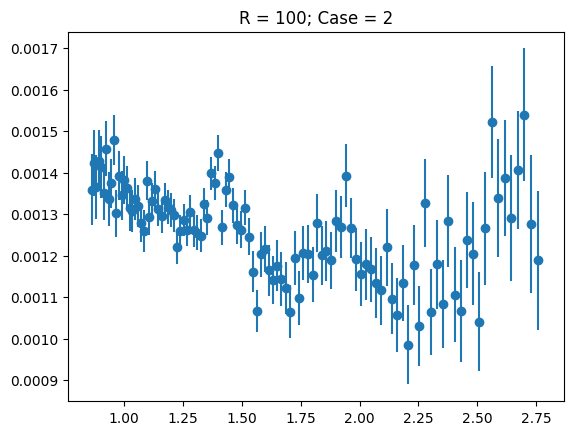

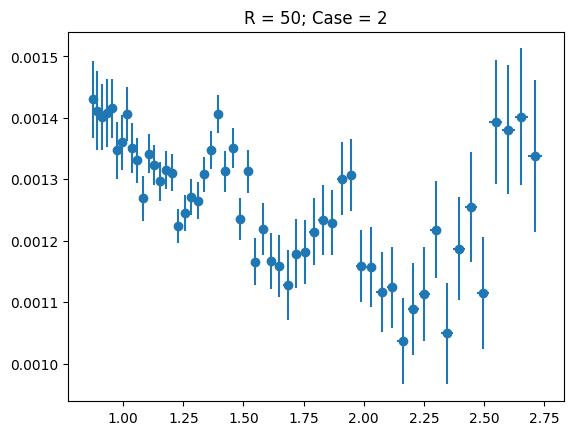

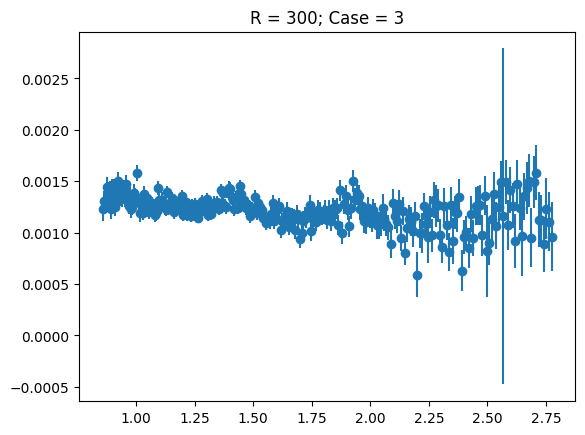

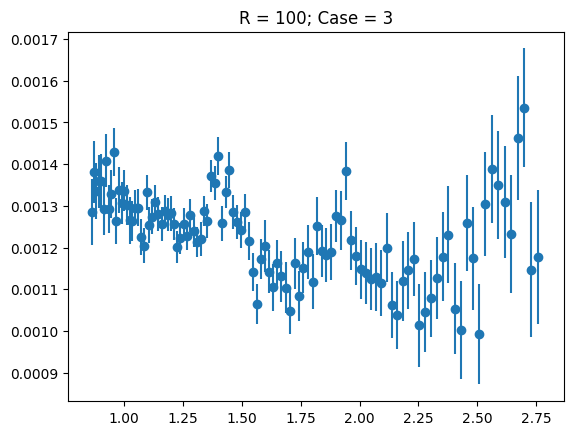

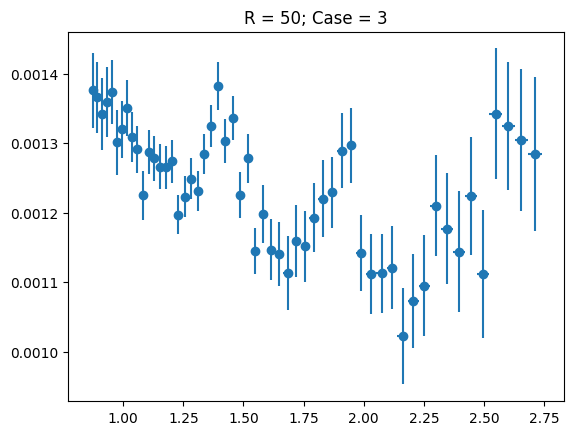

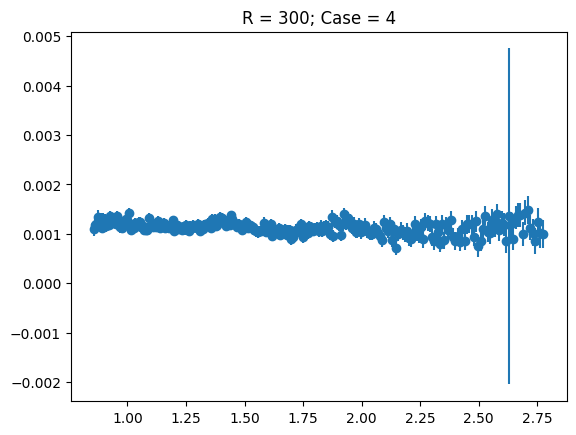

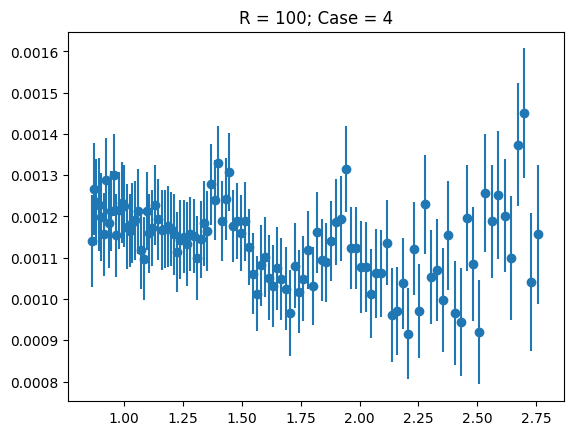

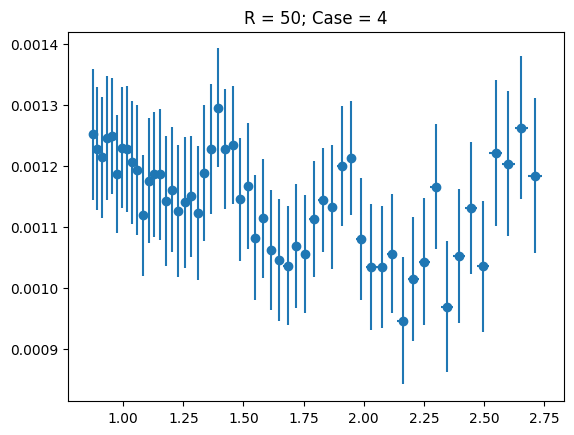

In [10]:
for i in range(1, len(new)):
    plt.errorbar(new[i].data['wave'], new[i].data['depth'], 
                 xerr=new[i].data['wave_err'], yerr=new[i].data['depth_err'],
                 marker='o', linestyle='')
    plt.title('R = {0}; Case = {1}'.format(new[i].header['RES'], new[i].header['CASE']))
    plt.show()

<ErrorbarContainer object of 3 artists>

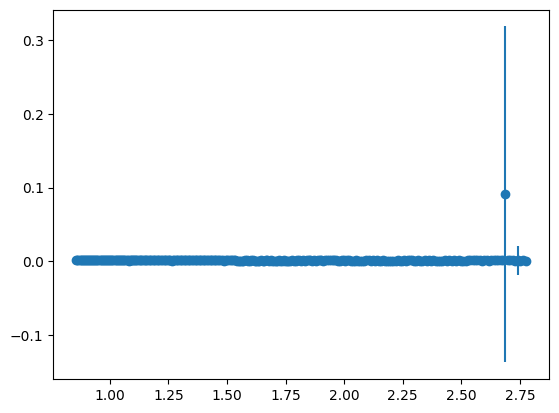

In [11]:
dat = np.loadtxt(filenames[-1])
plt.errorbar(dat[:,0], dat[:,2], xerr=dat[:,1], yerr=dat[:,3], marker='o', linestyle='')

In [12]:
new.close()